In [9]:
from submit import get_jobs_in_folder
from pathlib import Path
from collections import Counter

In [38]:
run_name = 'SymmCD-1'
mirages = Counter(map(int, get_jobs_in_folder(run_name, Path("/home/users/nus/kna/scratch/dft_runs")/run_name/"PBS")))

In [39]:
from utils import load_cifs
from worker_local import to_structure
def structure_or_none(structure):
    try:
        return to_structure(structure)
    except ValueError:
        return None
structure_sizes = load_cifs("/home/users/nus/kna/OkhotinDiffusion/generated_datasets/SymmCD/CIF-FMT-1000_original-symmcd-mp20.csv.gz"
                           ).map(structure_or_none).dropna().map(len)

/home/users/nus/kna/.conda/envs/vasp_computer/lib/python3.13/site-packages/pymatgen/io/cif.py:1290: UserWarning: Issues encountered while parsing CIF: 13 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/users/nus/kna/.conda/envs/vasp_computer/lib/python3.13/site-packages/pymatgen/io/cif.py:1290: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/users/nus/kna/.conda/envs/vasp_computer/lib/python3.13/site-packages/pymatgen/io/cif.py:1290: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/users/nus/kna/.conda/

In [40]:
import pandas as pd
counts = pd.Series(index=structure_sizes.index, data=structure_sizes.index.map(mirages) // 2, name="job_count")

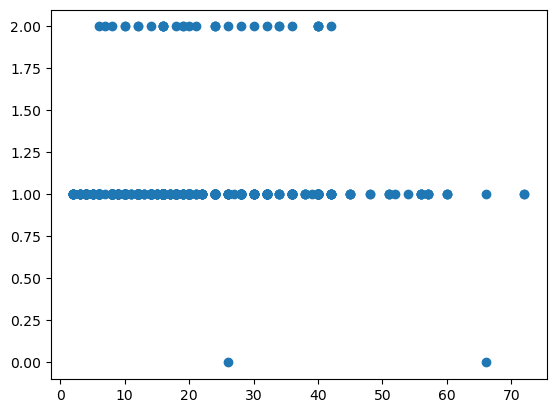

In [41]:
import matplotlib.pyplot as plt
fix, ax = plt.subplots()
ax.scatter(structure_sizes, counts);